# Adım 4: Keşifsel Veri Analizi (EDA)
## Spotify Tracks Dataset - Büyük Veri Projesi

Bu notebook, Delta Lake Silver katmanındaki Spotify verisi üzerinde kapsamlı bir keşifsel veri analizi gerçekleştirir.

**İçerik:**
- Temel istatistikler ve benzersiz değer sayıları
- Eksik değer analizi ve görselleştirilmesi
- Hedef değişken (popularity) dağılım analizi
- Sayısal değişkenlerin dağılımları
- Korelasyon matrisi
- Kategorik değişken analizi (track_genre, explicit)
- Zaman serisi analizi
- Popularity segmentasyonu
- Sanatçı analizi


## Kütüphanelerin Yüklenmesi ve Spark Oturumu


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, countDistinct, when, isnan, isnull,
    mean, stddev, min as spark_min, max as spark_max,
    hour, dayofweek, date_format, round as spark_round,
    desc, asc, lit, sum as spark_sum, avg,
    percentile_approx, skewness, kurtosis
)
from pyspark.sql.types import DoubleType
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import numpy as np
import os

# Grafik kayıt dizini
PLOT_DIR = "/home/jovyan/work/notebooks/eda_plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Matplotlib genel stil ayarları
plt.rcParams.update({
    "figure.facecolor": "#1e1e2f",
    "axes.facecolor": "#1e1e2f",
    "axes.edgecolor": "#444466",
    "axes.labelcolor": "#d0d0e0",
    "text.color": "#d0d0e0",
    "xtick.color": "#a0a0c0",
    "ytick.color": "#a0a0c0",
    "grid.color": "#333355",
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

ACCENT = "#7c4dff"
PALETTE = ["#7c4dff", "#00e5ff", "#ff4081", "#ffab40", "#69f0ae", "#ea80fc"]

spark = (
    SparkSession.builder
    .appName("Spotify EDA - Notebook")
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.2.0")
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension")
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog")
    .config("spark.sql.warehouse.dir", "/home/jovyan/work/spark-warehouse")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark oturumu başlatıldı.")

Spark oturumu başlatıldı.


## Delta Lake Silver Tablosunun Okunması

In [2]:

SILVER_PATH = "/home/jovyan/work/delta/silver/spotify_tracks"

df = spark.read.format("delta").load(SILVER_PATH)
print(f"Silver tablosu okundu: {SILVER_PATH}")

print(f"Toplam satır sayısı : {df.count()}")
print(f"Toplam kolon sayısı : {len(df.columns)}")
print(f"\nKolonlar: {df.columns}")
df.printSchema()

Silver tablosu okundu: /home/jovyan/work/delta/silver/spotify_tracks
Toplam satır sayısı : 24673
Toplam kolon sayısı : 31

Kolonlar: ['raw_json', 'kafka_timestamp', 'partition', 'offset', 'event_time', 'event_type', 'user_id', 'track_id', 'artists', 'album_name', 'track_name', 'track_genre', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'ingestion_time', 'event_timestamp', 'explicit_int', 'silver_ingestion_time']
root
 |-- raw_json: string (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)
 |-- partition: integer (nullable = true)
 |-- offset: long (nullable = true)
 |-- event_time: string (nullable = true)
 |-- event_type: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- track_id: string (nullable = true)
 |-- artists: string (nullable = true)
 |-- album_name: string (nullable = true)
 |-- track_name: 

## İlk Birkaç Satırın İncelenmesi


In [3]:
df.show(10, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------+---------+------+--------------------------------+------------------+---------+----------------------+----------------------+--------------------------------------+--------------------------------------+-----------+----------+-----------+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+--------------+-----------

## Temel İstatistikler (describe)


In [4]:
numeric_cols = [
    "popularity", "duration_ms", "danceability", "energy",
    "loudness", "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo"
]

# Mevcut kolonları filtrele (Gold kolonları dahil edilmedi)
existing_numeric = [c for c in numeric_cols if c in df.columns]

desc_df = df.select(existing_numeric).describe()
desc_df.show()

# Ek istatistikler: medyan, çarpıklık, basıklık
agg_exprs = []
for c in existing_numeric:
    agg_exprs.extend([
        percentile_approx(col(c), 0.5).alias(f"{c}_median"),
        skewness(col(c)).alias(f"{c}_skewness"),
        kurtosis(col(c)).alias(f"{c}_kurtosis"),
    ])
extra_stats = df.agg(*agg_exprs)
print("Medyan / Çarpıklık / Basıklık:")
extra_stats.show(truncate=False)

+-------+------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+-------------------+-------------------+------------------+------------------+
|summary|        popularity|       duration_ms|       danceability|             energy|          loudness|        speechiness|      acousticness|   instrumentalness|           liveness|           valence|             tempo|
+-------+------------------+------------------+-------------------+-------------------+------------------+-------------------+------------------+-------------------+-------------------+------------------+------------------+
|  count|             24673|             24673|              24673|              24673|             24673|              24673|             24673|              24673|              24673|             24673|             24673|
|   mean|31.081222388846108|235724.21866007376| 0.5783913751874519| 0.6193468340291002|-8.70667150326268

## Benzersiz Değer Sayıları


In [5]:
categorical_cols = ["track_genre", "artists", "album_name", "track_name"]
existing_cat = [c for c in categorical_cols if c in df.columns]

for c in existing_cat:
    n_unique = df.select(countDistinct(col(c))).collect()[0][0]
    print(f"{c:20s} → {n_unique:,} benzersiz değer")

if "user_id" in df.columns:
    n_users = df.select(countDistinct("user_id")).collect()[0][0]
    print(f"{'user_id':20s} → {n_users:,} benzersiz değer")

if "track_id" in df.columns:
    n_tracks = df.select(countDistinct("track_id")).collect()[0][0]
    print(f"{'track_id':20s} → {n_tracks:,} benzersiz değer")

track_genre          → 25 benzersiz değer
artists              → 7,642 benzersiz değer
album_name           → 11,572 benzersiz değer
track_name           → 18,389 benzersiz değer
user_id              → 4,954 benzersiz değer
track_id             → 21,776 benzersiz değer


## Olay Türü Dağılımı (event_type)

Event type dağılımı:
        event_type  count
track_stream_event  24673


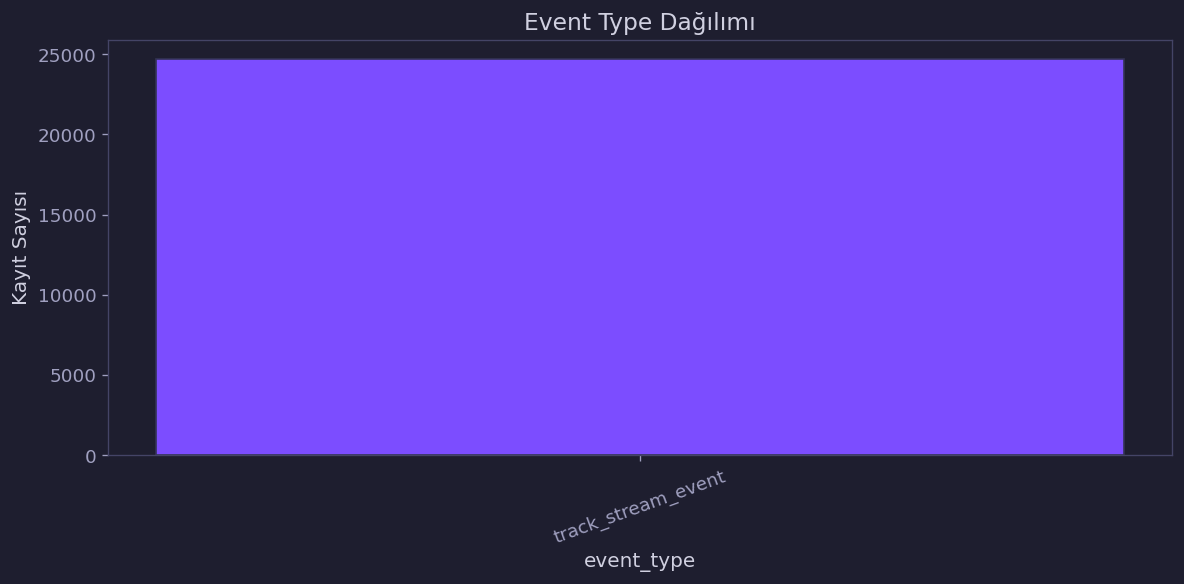

In [6]:
if "event_type" in df.columns:
    event_pdf = (
        df.groupBy("event_type")
        .count()
        .orderBy(desc("count"))
        .toPandas()
    )

    print("Event type dağılımı:")
    print(event_pdf.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 5))
    event_colors = [PALETTE[i % len(PALETTE)] for i in range(len(event_pdf))]
    ax.bar(event_pdf["event_type"], event_pdf["count"], color=event_colors, edgecolor="#333355")
    ax.set_title("Event Type Dağılımı")
    ax.set_xlabel("event_type")
    ax.set_ylabel("Kayıt Sayısı")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/00_event_type_distribution.png", bbox_inches="tight")
    plt.show()
else:
    print("event_type kolonu bulunamadı; olay dağılım analizi atlandı.")


## Eksik / Null Değer Analizi


               column  null_count  null_pct
             raw_json           0       0.0
      kafka_timestamp           0       0.0
            partition           0       0.0
               offset           0       0.0
           event_time           0       0.0
           event_type           0       0.0
              user_id           0       0.0
             track_id           0       0.0
              artists           0       0.0
           album_name           0       0.0
           track_name           0       0.0
          track_genre           0       0.0
           popularity           0       0.0
          duration_ms           0       0.0
             explicit           0       0.0
         danceability           0       0.0
               energy           0       0.0
                  key           0       0.0
             loudness           0       0.0
                 mode           0       0.0
          speechiness           0       0.0
         acousticness           

/tmp/ipykernel_122443/3372535036.py:32: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


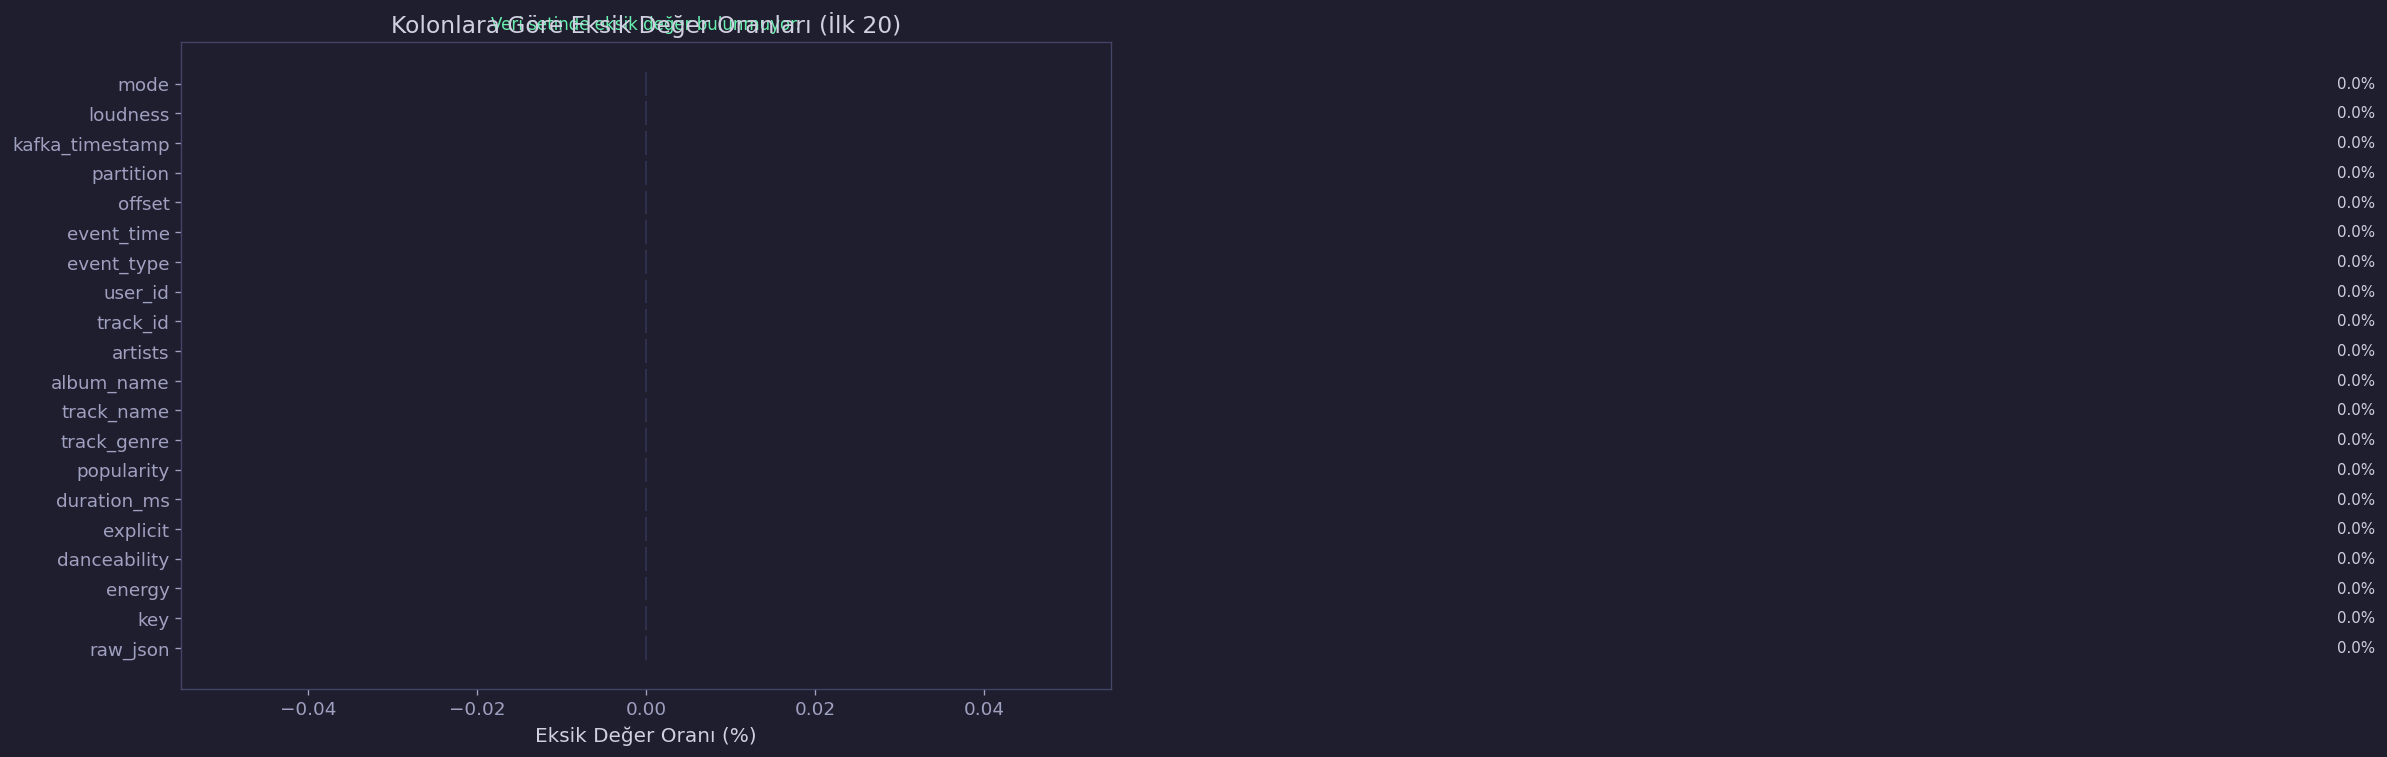

In [7]:
total_rows = df.count()
null_counts = []

for c in df.columns:
    if df.schema[c].dataType in (DoubleType(),):
        n_null = df.filter(col(c).isNull() | isnan(col(c))).count()
    else:
        n_null = df.filter(col(c).isNull()).count()
    pct = round(100.0 * n_null / total_rows, 2)
    null_counts.append((c, n_null, pct))

null_pdf = pd.DataFrame(null_counts, columns=["column", "null_count", "null_pct"])
null_pdf = null_pdf.sort_values(["null_pct", "null_count"], ascending=False)
print(null_pdf.to_string(index=False))

plot_pdf = null_pdf.head(20).sort_values("null_pct", ascending=True)
colors = [ACCENT if v > 0 else "#4b4b63" for v in plot_pdf["null_pct"]]

fig, ax = plt.subplots(figsize=(10, max(5, len(plot_pdf) * 0.35)))
bars = ax.barh(plot_pdf["column"], plot_pdf["null_pct"], color=colors, edgecolor="#333355")
ax.set_xlabel("Eksik Değer Oranı (%)")
ax.set_title("Kolonlara Göre Eksik Değer Oranları (İlk 20)")

for bar, val in zip(bars, plot_pdf["null_pct"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9, color="#d0d0e0")

if (null_pdf["null_count"] == 0).all():
    ax.text(0.5, 1.02, "Veri setinde eksik değer bulunmuyor.",
            transform=ax.transAxes, ha="center", color="#69f0ae", fontsize=10)

plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/01_missing_values.png", bbox_inches="tight")
plt.show()


## Zaman Serisi Analizi (Günlük/Saatlik Trendler)

Zaman serisi analizi için kullanılan kolon: event_timestamp
Günlük trend (ilk 10 gün):
       day  count
2026-04-28   5863
2026-05-09  18810


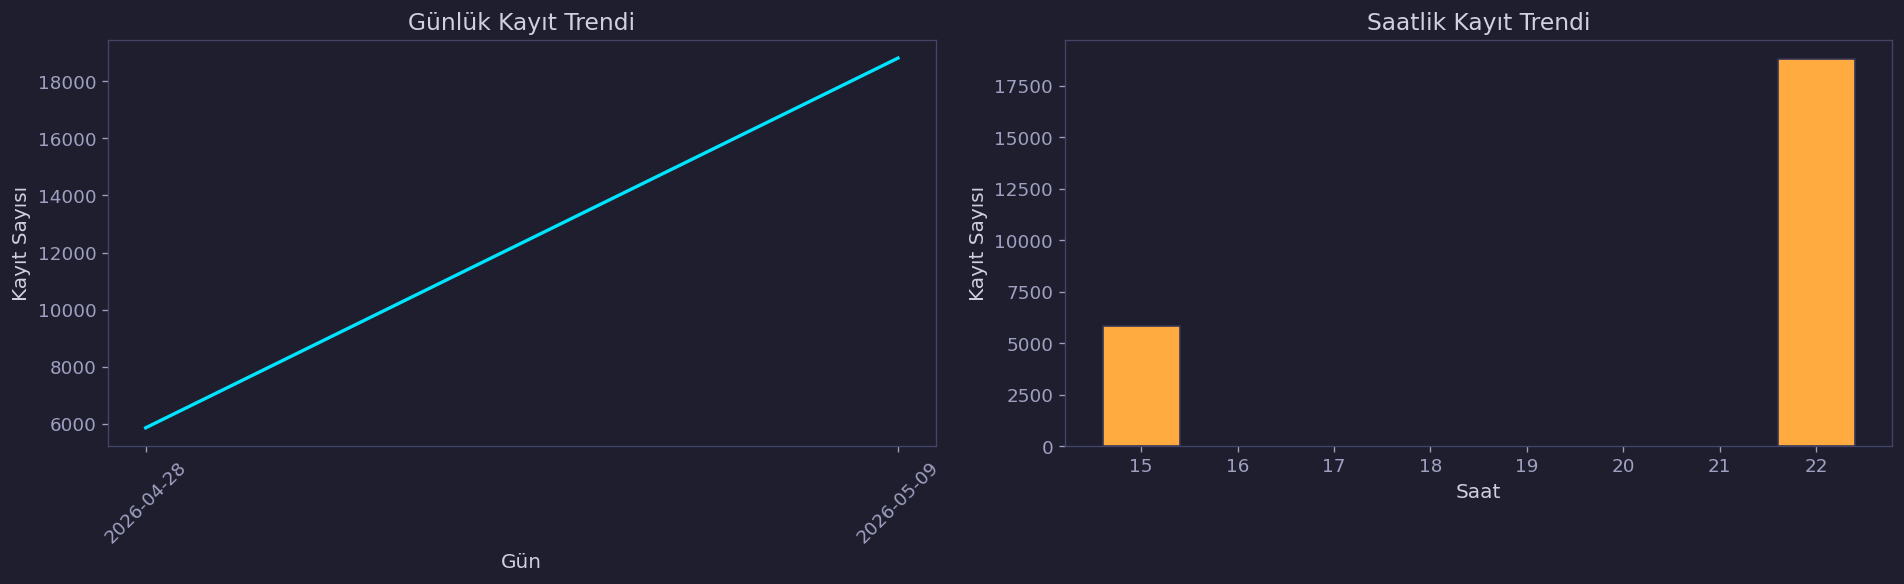

In [8]:
timestamp_candidates = ["event_timestamp", "kafka_timestamp", "ingestion_time", "event_time"]
ts_col = next((c for c in timestamp_candidates if c in df.columns), None)

if ts_col is None:
    print("Zaman serisi için uygun timestamp kolonu bulunamadı.")
else:
    ts_df = (
        df.withColumn("event_ts", col(ts_col).cast("timestamp"))
        .filter(col("event_ts").isNotNull())
    )

    if ts_df.limit(1).count() == 0:
        print(f"{ts_col} kolonu timestamp'e çevrilemedi; zaman serisi analizi atlandı.")
    else:
        daily_pdf = (
            ts_df.groupBy(date_format(col("event_ts"), "yyyy-MM-dd").alias("day"))
            .count()
            .orderBy("day")
            .toPandas()
        )

        hourly_pdf = (
            ts_df.groupBy(hour(col("event_ts")).alias("hour"))
            .count()
            .orderBy("hour")
            .toPandas()
        )

        print(f"Zaman serisi analizi için kullanılan kolon: {ts_col}")
        print("Günlük trend (ilk 10 gün):")
        print(daily_pdf.head(10).to_string(index=False))

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        axes[0].plot(daily_pdf["day"], daily_pdf["count"], color="#00e5ff", linewidth=2)
        axes[0].set_title("Günlük Kayıt Trendi")
        axes[0].set_xlabel("Gün")
        axes[0].set_ylabel("Kayıt Sayısı")
        axes[0].tick_params(axis="x", rotation=45)

        axes[1].bar(hourly_pdf["hour"], hourly_pdf["count"], color="#ffab40", edgecolor="#333355")
        axes[1].set_title("Saatlik Kayıt Trendi")
        axes[1].set_xlabel("Saat")
        axes[1].set_ylabel("Kayıt Sayısı")

        plt.tight_layout()
        plt.savefig(f"{PLOT_DIR}/07_time_series.png", bbox_inches="tight")
        plt.show()


## Hedef Değişken Analizi - Popularity Dağılımı


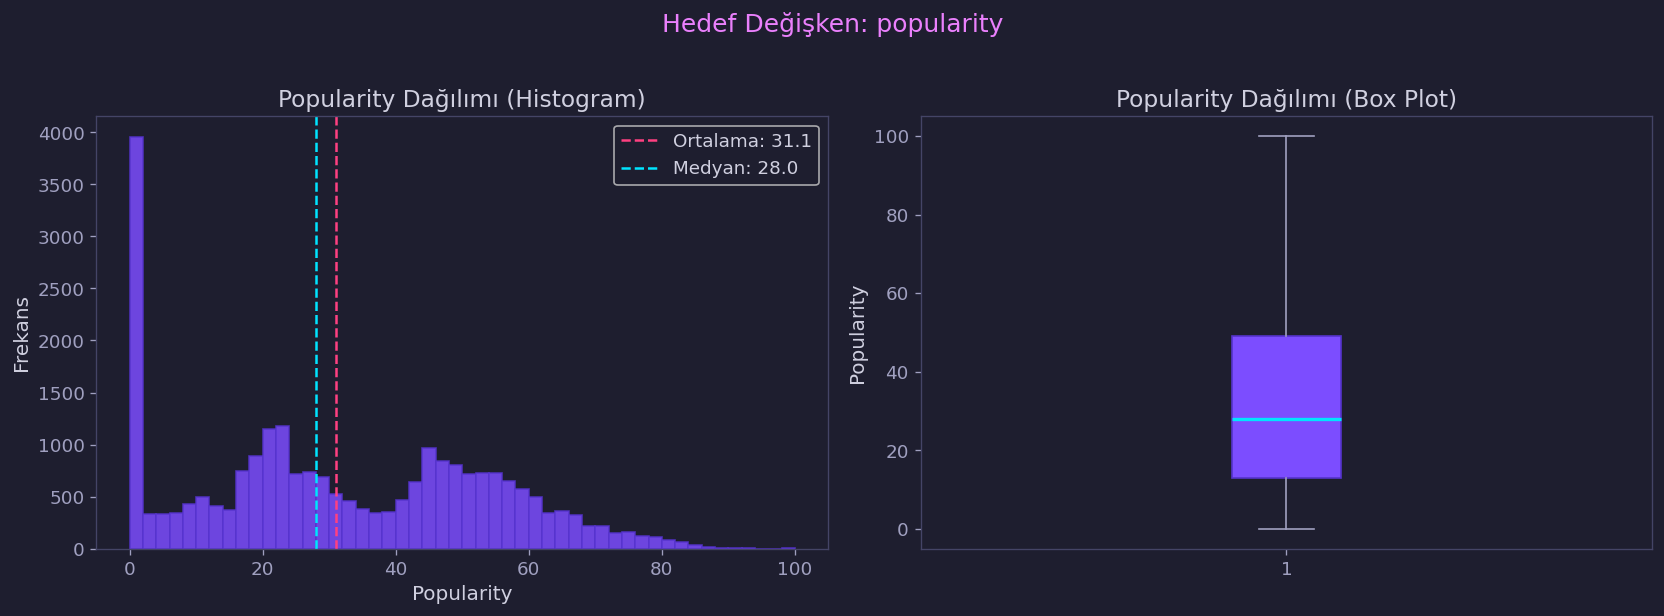

In [9]:
pop_pdf = df.select("popularity").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(pop_pdf["popularity"], bins=50, color=ACCENT, edgecolor="#5533cc", alpha=0.85)
axes[0].set_title("Popularity Dağılımı (Histogram)")
axes[0].set_xlabel("Popularity")
axes[0].set_ylabel("Frekans")
axes[0].axvline(pop_pdf["popularity"].mean(), color="#ff4081", linestyle="--", label=f'Ortalama: {pop_pdf["popularity"].mean():.1f}')
axes[0].axvline(pop_pdf["popularity"].median(), color="#00e5ff", linestyle="--", label=f'Medyan: {pop_pdf["popularity"].median():.1f}')
axes[0].legend()

bp = axes[1].boxplot(pop_pdf["popularity"].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor=ACCENT, color="#5533cc"),
                     medianprops=dict(color="#00e5ff", linewidth=2),
                     whiskerprops=dict(color="#a0a0c0"),
                     capprops=dict(color="#a0a0c0"),
                     flierprops=dict(marker="o", markerfacecolor="#ff4081", markersize=3, alpha=0.4))
axes[1].set_title("Popularity Dağılımı (Box Plot)")
axes[1].set_ylabel("Popularity")

plt.suptitle("Hedef Değişken: popularity", fontsize=15, color="#ea80fc", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/02_popularity_distribution.png", bbox_inches="tight")
plt.show()

## Sayısal Değişkenlerin Dağılım Analizi (Histogramlar)


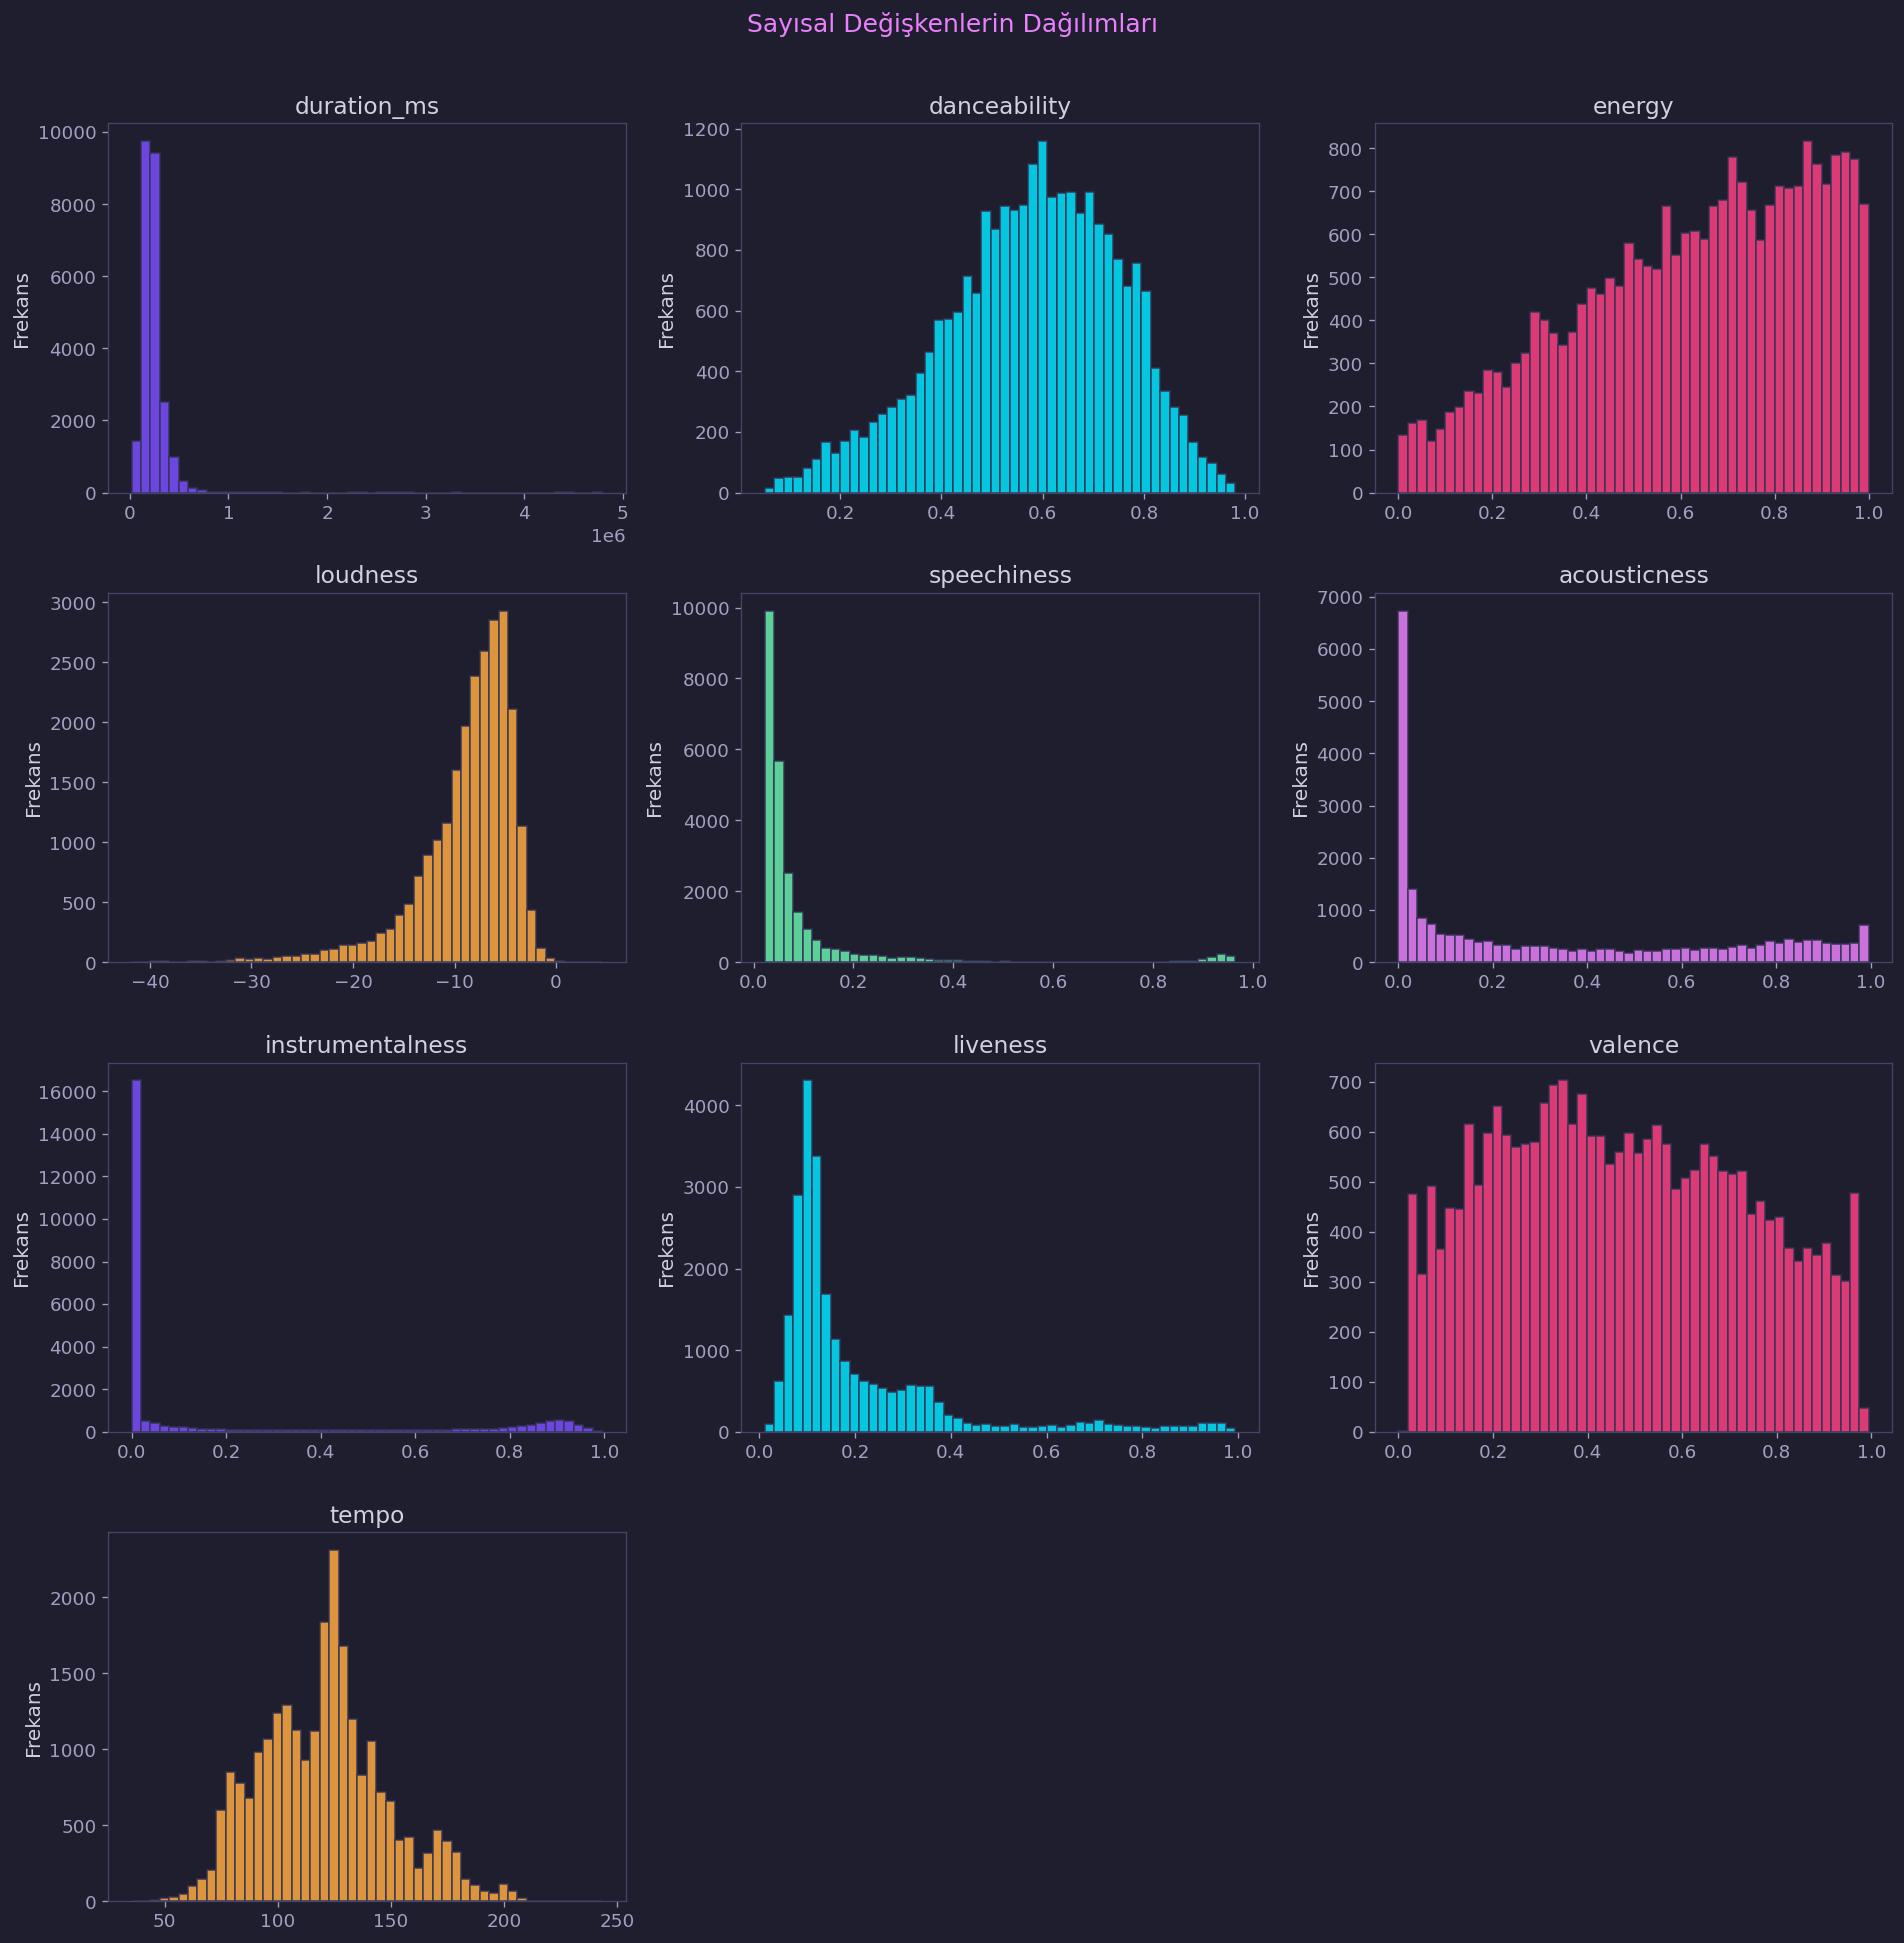

In [10]:
plot_cols = [c for c in existing_numeric if c != "popularity"]
n = len(plot_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, c in enumerate(plot_cols):
    data = df.select(c).dropna().toPandas()
    axes[i].hist(data[c], bins=50, color=PALETTE[i % len(PALETTE)], edgecolor="#333355", alpha=0.85)
    axes[i].set_title(c)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frekans")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Sayısal Değişkenlerin Dağılımları", fontsize=15, color="#ea80fc", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/03_numeric_distributions.png", bbox_inches="tight")
plt.show()

## Korelasyon Matrisi


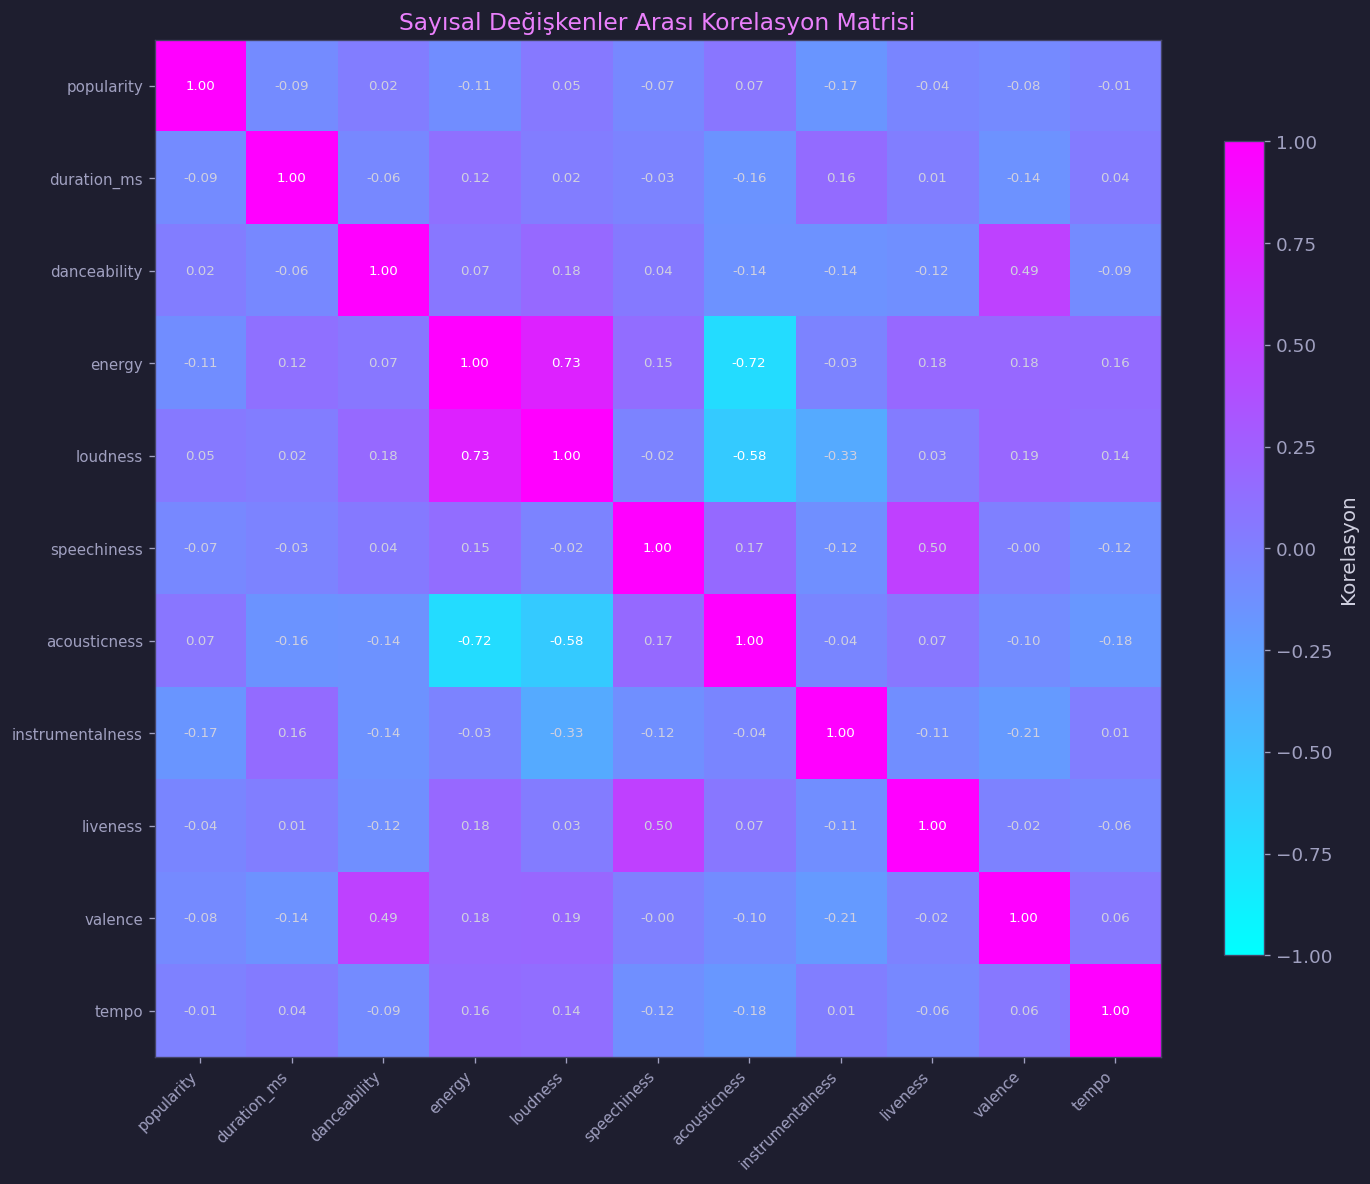

In [11]:
corr_cols = [c for c in existing_numeric if c in df.columns]
corr_pdf = df.select(corr_cols).toPandas()
corr_matrix = corr_pdf.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix.values, cmap="cool", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        color = "white" if abs(val) > 0.5 else "#d0d0e0"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label="Korelasyon")
ax.set_title("Sayısal Değişkenler Arası Korelasyon Matrisi", fontsize=14, color="#ea80fc")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/04_correlation_matrix.png", bbox_inches="tight")
plt.show()

## Popularity ile En Güçlü Korelasyonlar


In [12]:
if "popularity" in corr_matrix.columns:
    pop_corr = corr_matrix["popularity"].drop("popularity").sort_values(key=abs, ascending=False)
    print("\nPopularity ile korelasyonlar (büyükten küçüğe):\n")
    for feat, val in pop_corr.items():
        bar = "█" * int(abs(val) * 30)
        sign = "+" if val > 0 else "-"
        print(f"  {feat:25s}  {sign}{abs(val):.4f}  {bar}")


Popularity ile korelasyonlar (büyükten küçüğe):

  instrumentalness           -0.1709  █████
  energy                     -0.1073  ███
  duration_ms                -0.0931  ██
  valence                    -0.0810  ██
  acousticness               +0.0713  ██
  speechiness                -0.0671  ██
  loudness                   +0.0541  █
  liveness                   -0.0440  █
  danceability               +0.0184  
  tempo                      -0.0083  


## Kategorik Değişken - track_genre Analizi



Toplam tür sayısı: 25

En yaygın 20 tür:
  track_genre  count  avg_popularity  avg_energy  avg_danceability
     acoustic   2550           43.42        0.43              0.55
  alternative   1000           24.34        0.72              0.56
  death-metal   1000           32.17        0.93              0.37
     cantopop   1000           34.74        0.46              0.55
        blues   1000           31.19        0.58              0.57
    breakbeat   1000           20.12        0.85              0.65
        dance   1000           22.69        0.71              0.69
       brazil   1000           44.67        0.62              0.56
   deep-house   1000           44.81        0.74              0.71
        chill   1000           53.65        0.43              0.66
    bluegrass   1000           25.68        0.53              0.53
      country   1000           17.03        0.60              0.56
      british   1000           43.80        0.51              0.50
    dancehall   1000

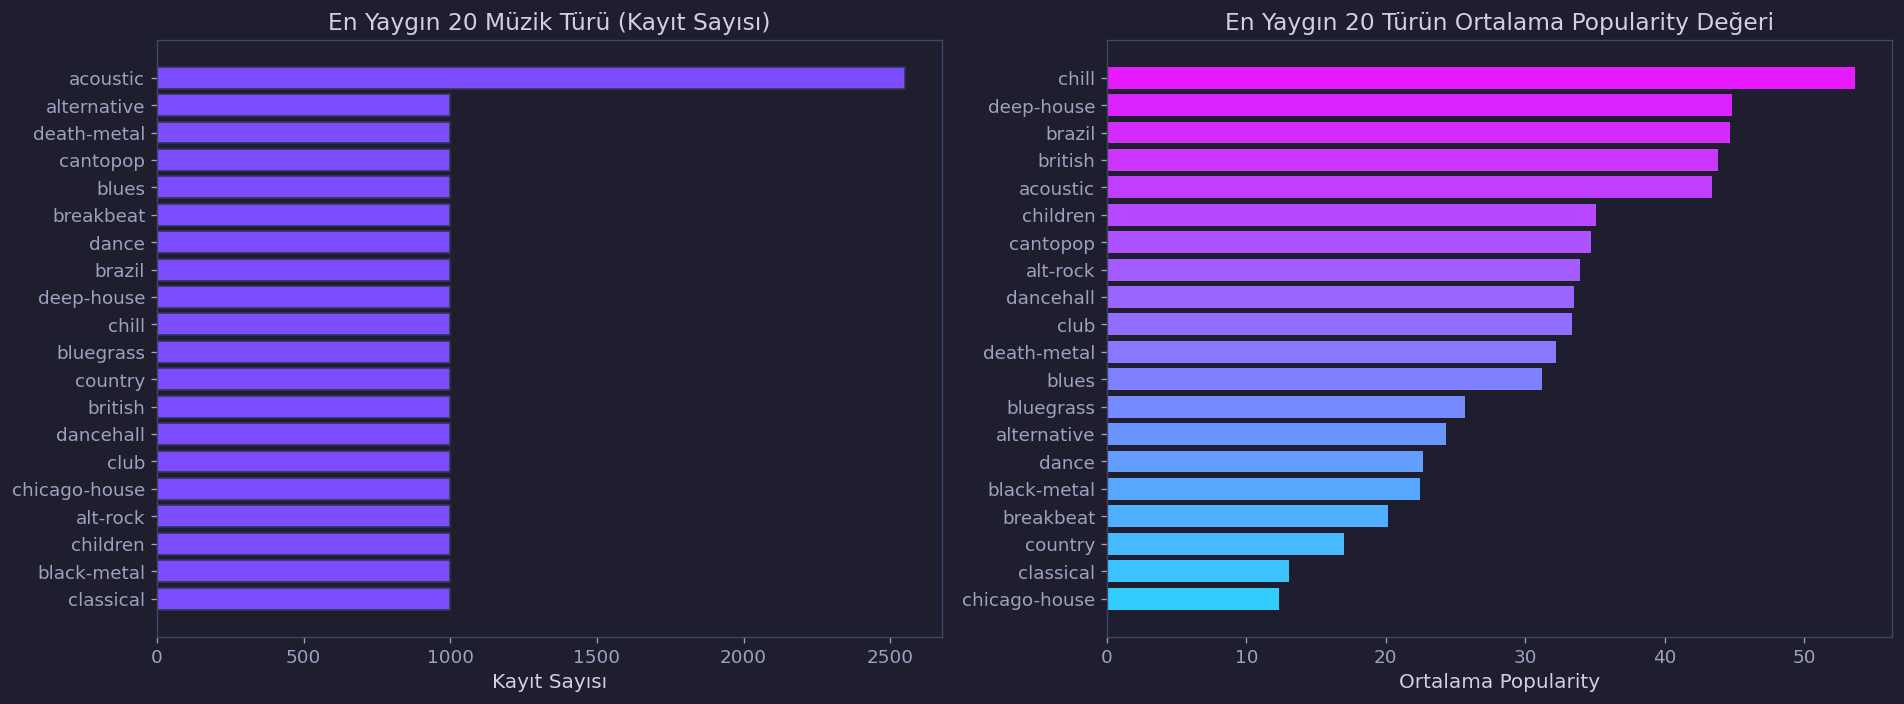

In [13]:
if "track_genre" in df.columns:
    genre_counts = (
        df.groupBy("track_genre")
        .agg(
            count("*").alias("count"),
            spark_round(avg("popularity"), 2).alias("avg_popularity"),
            spark_round(avg("energy"), 2).alias("avg_energy"),
            spark_round(avg("danceability"), 2).alias("avg_danceability"),
        )
        .orderBy(desc("count"))
    )

    genre_pdf = genre_counts.toPandas()
    print(f"\nToplam tür sayısı: {len(genre_pdf)}")
    print("\nEn yaygın 20 tür:")
    print(genre_pdf.head(20).to_string(index=False))

    top20 = genre_pdf.head(20)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    bars = axes[0].barh(top20["track_genre"][::-1], top20["count"][::-1], color=ACCENT, edgecolor="#333355")
    axes[0].set_title("En Yaygın 20 Müzik Türü (Kayıt Sayısı)")
    axes[0].set_xlabel("Kayıt Sayısı")

    top20_sorted = top20.sort_values("avg_popularity", ascending=True)
    colors = plt.cm.cool(np.linspace(0.2, 0.9, len(top20_sorted)))
    axes[1].barh(top20_sorted["track_genre"], top20_sorted["avg_popularity"], color=colors)
    axes[1].set_title("En Yaygın 20 Türün Ortalama Popularity Değeri")
    axes[1].set_xlabel("Ortalama Popularity")

    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/05_genre_analysis.png", bbox_inches="tight")
    plt.show()

## Explicit İçerik Analizi


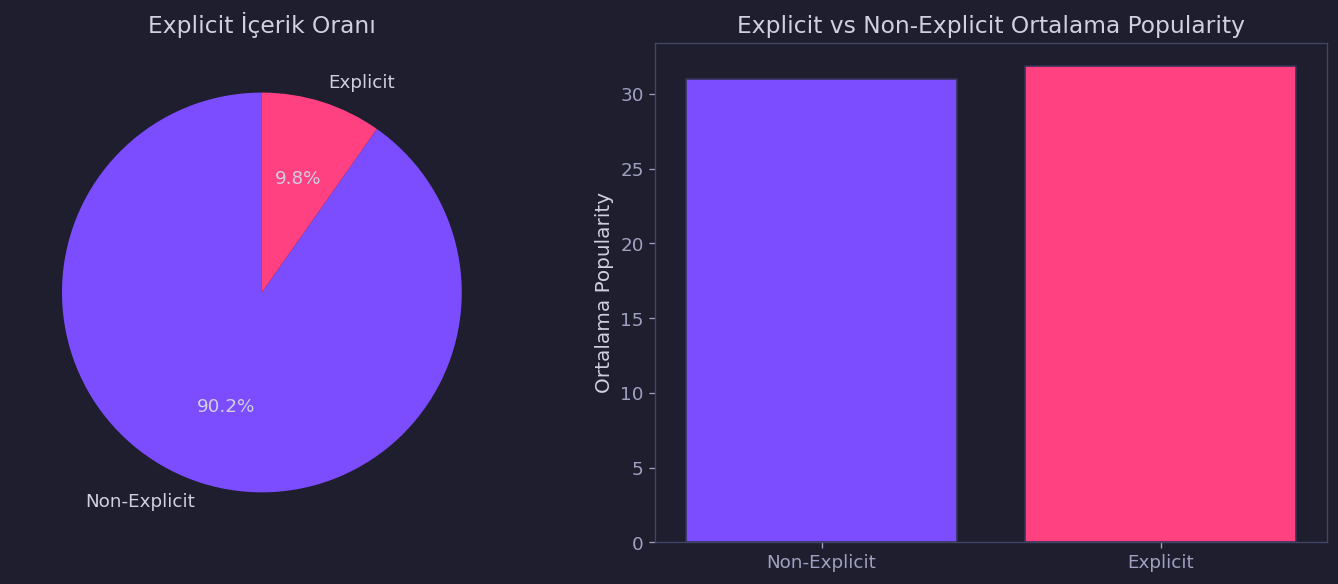

In [14]:
if "explicit" in df.columns or "explicit_int" in df.columns:
    exp_col = "explicit_int" if "explicit_int" in df.columns else "explicit"
    exp_counts = df.groupBy(exp_col).count().toPandas()
    exp_pop = df.groupBy(exp_col).agg(
        spark_round(avg("popularity"), 2).alias("avg_popularity")
    ).toPandas()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    labels = ["Non-Explicit", "Explicit"]
    sizes = exp_counts.sort_values(exp_col)["count"].values
    axes[0].pie(sizes, labels=labels, autopct="%1.1f%%",
                colors=[ACCENT, "#ff4081"], startangle=90, textprops={"color": "#d0d0e0"})
    axes[0].set_title("Explicit İçerik Oranı")

    exp_pop_sorted = exp_pop.sort_values(exp_col)
    axes[1].bar(labels, exp_pop_sorted["avg_popularity"], color=[ACCENT, "#ff4081"], edgecolor="#333355")
    axes[1].set_title("Explicit vs Non-Explicit Ortalama Popularity")
    axes[1].set_ylabel("Ortalama Popularity")

    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/06_explicit_analysis.png", bbox_inches="tight")
    plt.show()

## Scatter Plot - Energy vs Danceability (Popularity ile renkli)


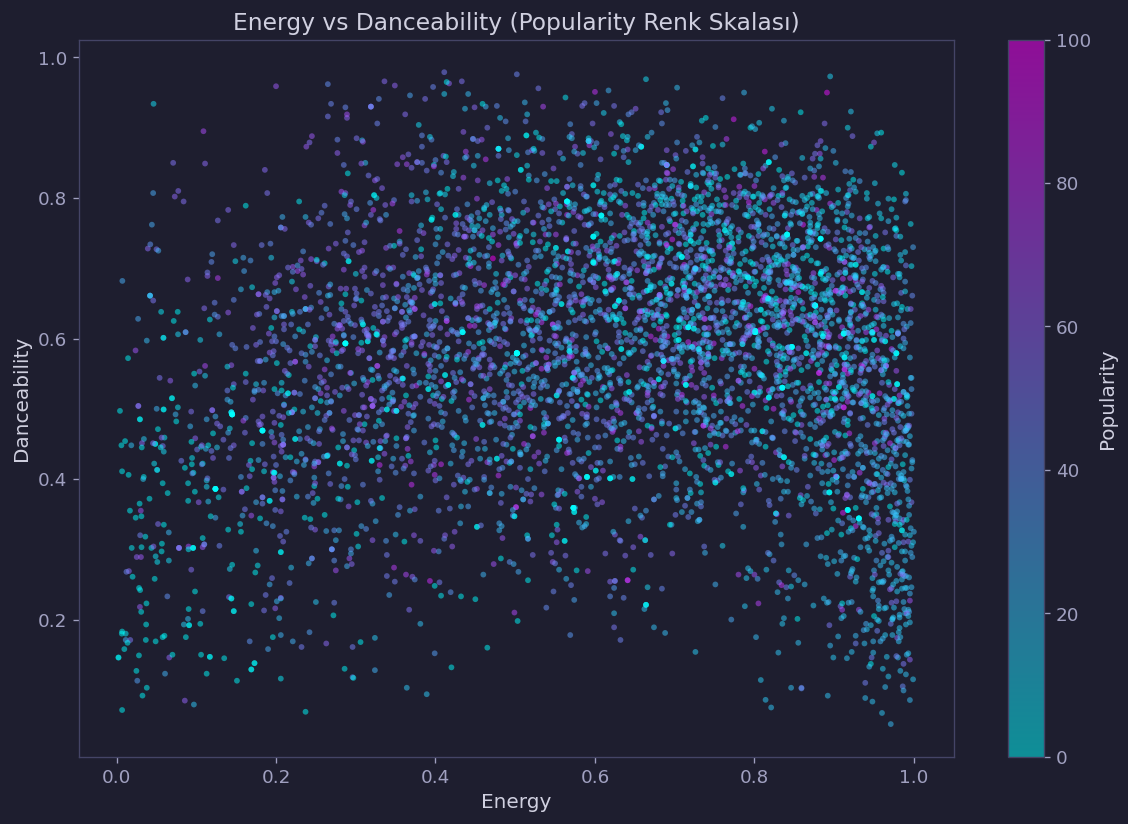

Scatter plot kaydedildi.


In [15]:
sample_pdf = df.select("energy", "danceability", "popularity").dropna().limit(5000).toPandas()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    sample_pdf["energy"], sample_pdf["danceability"],
    c=sample_pdf["popularity"], cmap="cool", alpha=0.5, s=12, edgecolors="none"
)
plt.colorbar(scatter, ax=ax, label="Popularity")
ax.set_xlabel("Energy")
ax.set_ylabel("Danceability")
ax.set_title("Energy vs Danceability (Popularity Renk Skalası)")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/08_energy_vs_danceability.png", bbox_inches="tight")
plt.show()
print("Scatter plot kaydedildi.")

## Tempo Segment Analizi

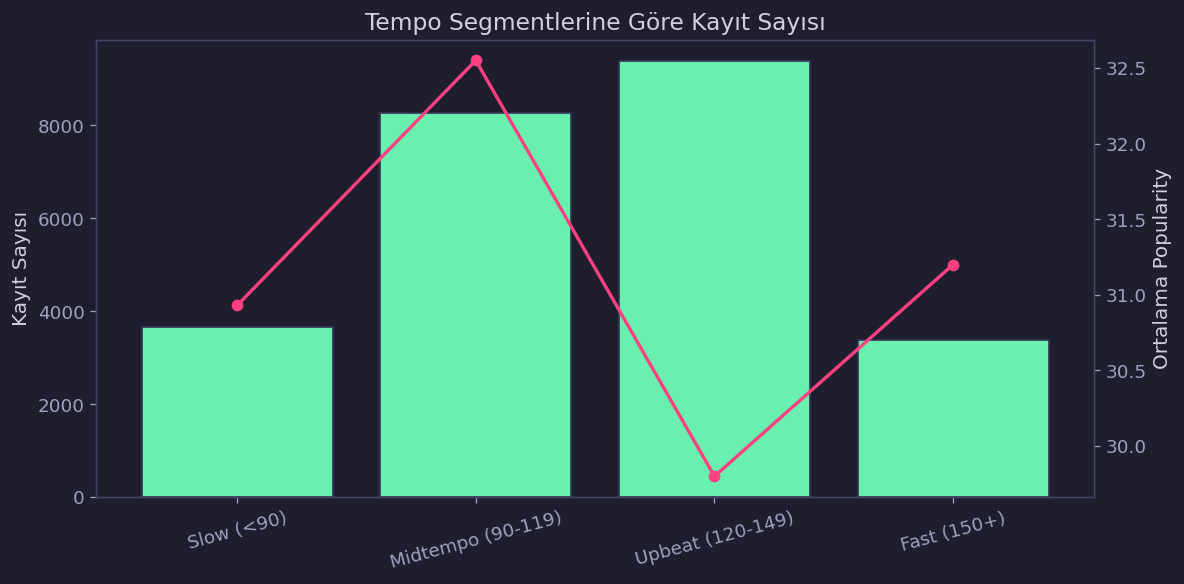

In [16]:
if "tempo" in df.columns:
    tempo_pdf = (
        df.withColumn(
            "tempo_bucket",
            when(col("tempo") < 90, "Slow (<90)")
            .when(col("tempo") < 120, "Midtempo (90-119)")
            .when(col("tempo") < 150, "Upbeat (120-149)")
            .otherwise("Fast (150+)")
        )
        .groupBy("tempo_bucket")
        .agg(
            count("*").alias("count"),
            spark_round(avg("popularity"), 2).alias("avg_popularity")
        )
        .toPandas()
    )

    order = ["Slow (<90)", "Midtempo (90-119)", "Upbeat (120-149)", "Fast (150+)"]
    tempo_pdf["tempo_bucket"] = pd.Categorical(tempo_pdf["tempo_bucket"], categories=order, ordered=True)
    tempo_pdf = tempo_pdf.sort_values("tempo_bucket")

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(tempo_pdf["tempo_bucket"], tempo_pdf["count"], color="#69f0ae", edgecolor="#333355")
    ax1.set_ylabel("Kayıt Sayısı")
    ax1.set_title("Tempo Segmentlerine Göre Kayıt Sayısı")
    ax1.tick_params(axis="x", rotation=15)

    ax2 = ax1.twinx()
    ax2.plot(tempo_pdf["tempo_bucket"], tempo_pdf["avg_popularity"], color="#ff4081", marker="o", linewidth=2)
    ax2.set_ylabel("Ortalama Popularity")

    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/09_tempo_bucket.png", bbox_inches="tight")
    plt.show()
else:
    print("tempo kolonu bulunamadı; tempo segment analizi atlandı.")


## Valence (Mood) ve Popularity İlişkisi

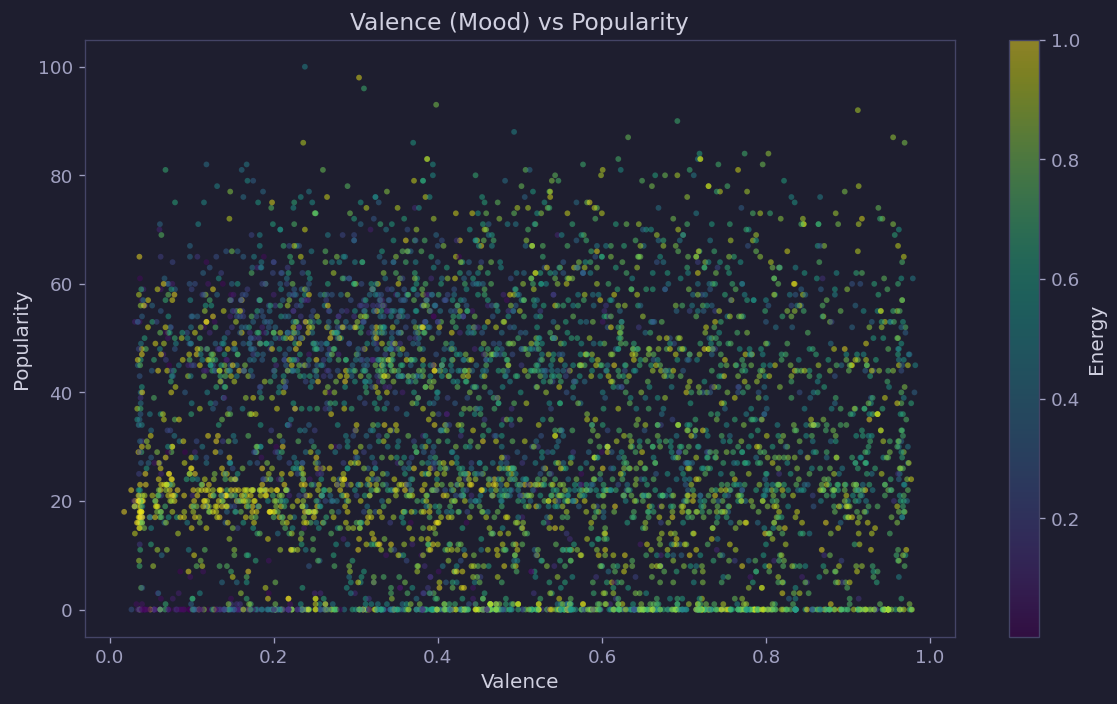

In [17]:
if "valence" in df.columns and "popularity" in df.columns:
    use_cols = ["valence", "popularity"] + (["energy"] if "energy" in df.columns else [])
    mood_pdf = df.select(*use_cols).dropna().limit(5000).toPandas()

    fig, ax = plt.subplots(figsize=(10, 6))
    if "energy" in mood_pdf.columns:
        sc = ax.scatter(
            mood_pdf["valence"], mood_pdf["popularity"],
            c=mood_pdf["energy"], cmap="viridis", alpha=0.5, s=12, edgecolors="none"
        )
        plt.colorbar(sc, ax=ax, label="Energy")
    else:
        ax.scatter(mood_pdf["valence"], mood_pdf["popularity"], color="#00e5ff", alpha=0.5, s=12, edgecolors="none")

    ax.set_title("Valence (Mood) vs Popularity")
    ax.set_xlabel("Valence")
    ax.set_ylabel("Popularity")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/10_mood_vs_popularity.png", bbox_inches="tight")
    plt.show()
else:
    print("valence/popularity kolonları bulunamadı; mood analizi atlandı.")


## Popularity Segmentasyonu


Popularity Segmentleri Özet:
        pop_segment  count  avg_energy  avg_danceability  avg_valence  avg_acousticness
       Düşük (0-20)   8834       0.654             0.583        0.492             0.262
       Orta (21-50)  10075       0.627             0.567        0.474             0.374
     Yüksek (51-75)   5315       0.542             0.590        0.443             0.399
Çok Yüksek (76-100)    449       0.683             0.607        0.499             0.162


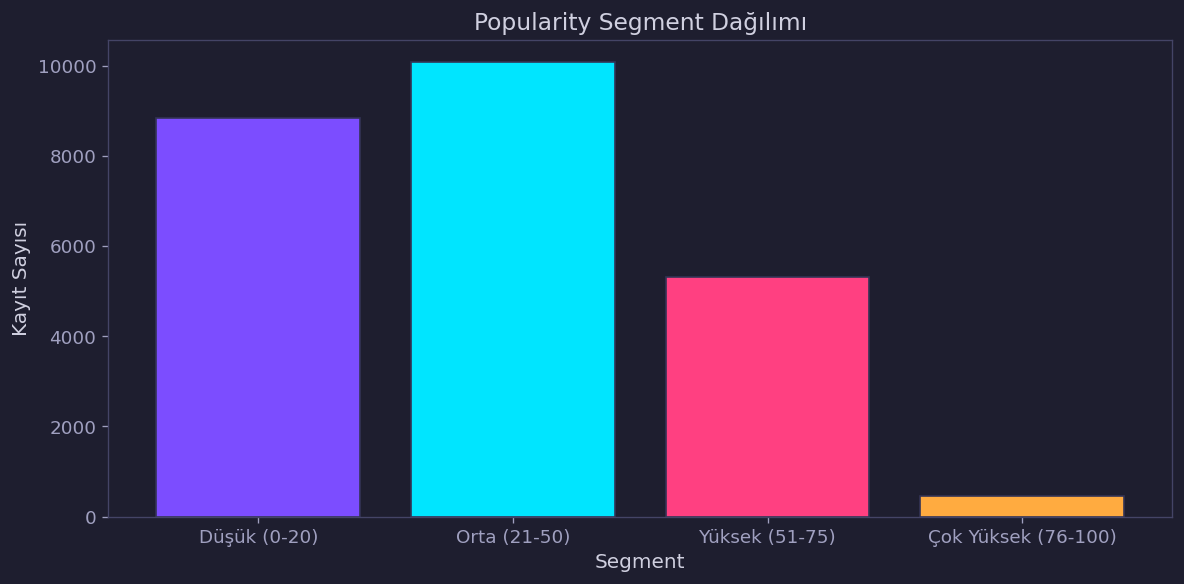

Popularity segmentasyonu kaydedildi.


In [18]:
pop_segments = (
    df.withColumn(
        "pop_segment",
        when(col("popularity") <= 20, "Düşük (0-20)")
        .when(col("popularity") <= 50, "Orta (21-50)")
        .when(col("popularity") <= 75, "Yüksek (51-75)")
        .otherwise("Çok Yüksek (76-100)")
    )
    .groupBy("pop_segment")
    .agg(
        count("*").alias("count"),
        spark_round(avg("energy"), 3).alias("avg_energy"),
        spark_round(avg("danceability"), 3).alias("avg_danceability"),
        spark_round(avg("valence"), 3).alias("avg_valence"),
        spark_round(avg("acousticness"), 3).alias("avg_acousticness"),
    )
    .orderBy("pop_segment")
    .toPandas()
)

print("Popularity Segmentleri Özet:")
print(pop_segments.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
seg_order = ["Düşük (0-20)", "Orta (21-50)", "Yüksek (51-75)", "Çok Yüksek (76-100)"]
pop_segments["pop_segment"] = pd.Categorical(pop_segments["pop_segment"], categories=seg_order, ordered=True)
pop_segments = pop_segments.sort_values("pop_segment")

ax.bar(pop_segments["pop_segment"], pop_segments["count"], color=PALETTE[:4], edgecolor="#333355")
ax.set_title("Popularity Segment Dağılımı")
ax.set_ylabel("Kayıt Sayısı")
ax.set_xlabel("Segment")
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/11_popularity_segments.png", bbox_inches="tight")
plt.show()
print("Popularity segmentasyonu kaydedildi.")

## En Popüler Sanatçılar (Top 20)


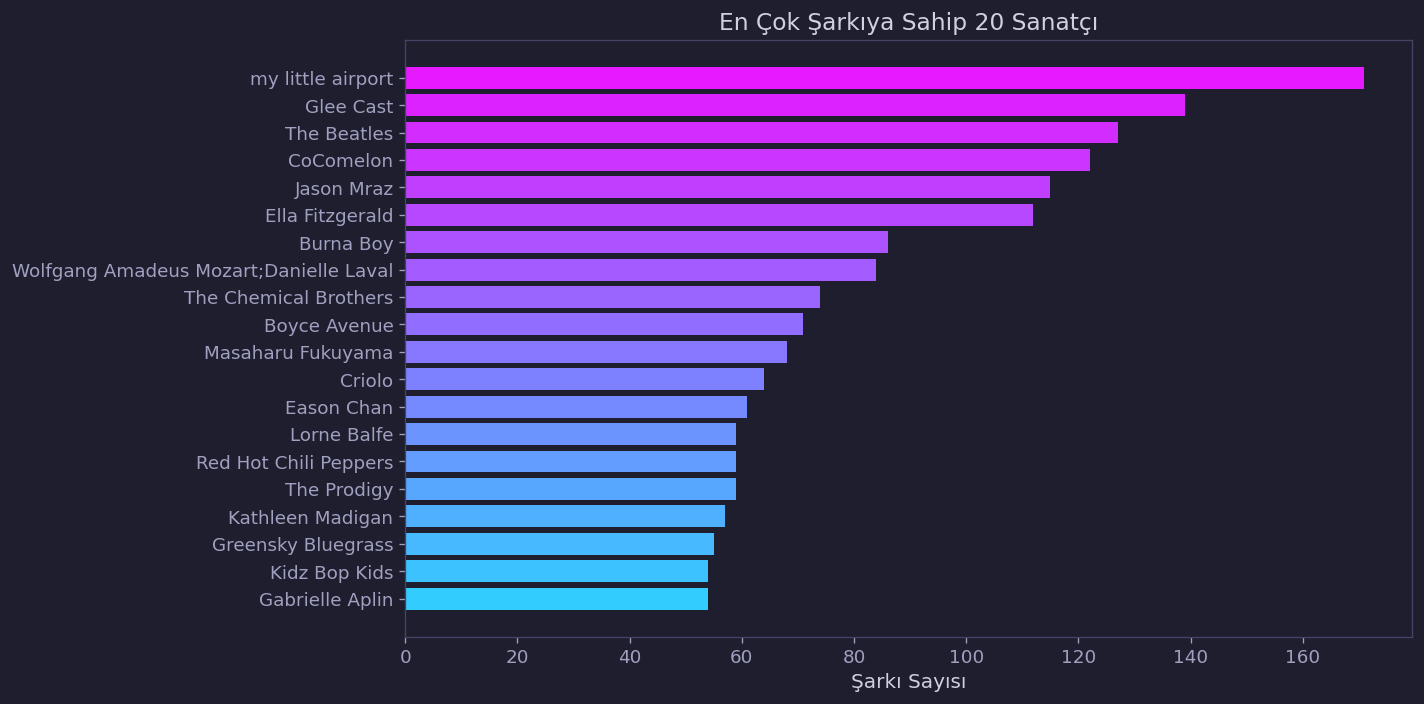

Sanatçı analizi kaydedildi.


In [19]:
if "artists" in df.columns:
    top_artists = (
        df.groupBy("artists")
        .agg(
            count("*").alias("track_count"),
            spark_round(avg("popularity"), 2).alias("avg_popularity"),
        )
        .orderBy(desc("track_count"))
        .limit(20)
        .toPandas()
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = plt.cm.cool(np.linspace(0.2, 0.9, len(top_artists)))
    ax.barh(top_artists["artists"][::-1], top_artists["track_count"][::-1], color=colors)
    ax.set_title("En Çok Şarkıya Sahip 20 Sanatçı")
    ax.set_xlabel("Şarkı Sayısı")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/12_top_artists.png", bbox_inches="tight")
    plt.show()
    print("Sanatçı analizi kaydedildi.")

## EDA Özet ve Sonuç


In [20]:
total = df.count()
n_cols = len(df.columns)
n_genres = df.select(countDistinct("track_genre")).collect()[0][0] if "track_genre" in df.columns else "N/A"
avg_pop = df.agg(spark_round(avg("popularity"), 2)).collect()[0][0]

plot_files = sorted([f for f in os.listdir(PLOT_DIR) if f.lower().endswith(".png")])

print("=" * 60)
print("           EDA ÖZET RAPORU - Spotify Tracks Dataset")
print("=" * 60)
print(f"  Toplam kayıt sayısı       : {total:,}")
print(f"  Toplam kolon sayısı       : {n_cols}")
print(f"  Benzersiz tür sayısı      : {n_genres}")
print(f"  Ortalama popularity       : {avg_pop}")
print(f"  Grafik sayısı             : {len(plot_files)}")
print(f"  Grafik dizini             : {PLOT_DIR}")
print("=" * 60)
print()
print("Sonraki adım → Adım 5: Özellik Mühendisliği (Feature Engineering)")
print("  ML modeli için ek özellikler ve VectorAssembler hazırlanacak.")
print()
print("Sonraki adım → Adım 6: Makine Öğrenmesi (5 Regresyon Modeli)")
print("  Hedef değişken: popularity")
print("  Modeller: Linear Regression, Decision Tree, Random Forest,")
print("            GBT Regressor, Generalized Linear Regression")
print("=" * 60)

spark.stop()
print("\nSpark oturumu kapatıldı. EDA tamamlandı ✓")


           EDA ÖZET RAPORU - Spotify Tracks Dataset
  Toplam kayıt sayısı       : 24,673
  Toplam kolon sayısı       : 31
  Benzersiz tür sayısı      : 25
  Ortalama popularity       : 31.08
  Grafik sayısı             : 13
  Grafik dizini             : /home/jovyan/work/notebooks/eda_plots

Sonraki adım → Adım 5: Özellik Mühendisliği (Feature Engineering)
  ML modeli için ek özellikler ve VectorAssembler hazırlanacak.

Sonraki adım → Adım 6: Makine Öğrenmesi (5 Regresyon Modeli)
  Hedef değişken: popularity
  Modeller: Linear Regression, Decision Tree, Random Forest,
            GBT Regressor, Generalized Linear Regression

Spark oturumu kapatıldı. EDA tamamlandı ✓
